# Stimulus-level last-frame decay associations

For every stimulus, this notebook computes:

1. pixel or model-feature correlation with the movie's last frame;
2. raw dynamic-neural correlation with its response at the last frame; and
3. raw dynamic-neural similarity to the static last-frame response.

Each curve can be Gaussian-smoothed only through its peak, then is fitted backward with $b + a\exp(-\mathrm{lag}/\tau)$. The first two peaks are fixed at the last frame; the static–dynamic curve ends at its own peak inside `dynamic_peak_window_ms`. Larger $\tau$ means a slower decay. The final scatter compares the static last-frame/2250-ms population-vector correlation with the static–dynamic decay.

In [1]:
import csv
import os
import sys
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import yaml

ENV = os.getenv("MY_ENV", "tiziano_mac_mini")
PROJECT_ROOT = next(
    path for path in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
    if (path / "config.yaml").is_file()
)
with open(PROJECT_ROOT / "config.yaml", "r") as file:
    paths = yaml.safe_load(file)[ENV]["paths"]
# end with open
sys.path.extend([paths["src_path"], paths["useful_stuff_path"]])

from project_specific_utils.last_frame_decay import (
    compute_last_frame_decay_measures,
    load_last_frame_decay_data,
    plot_decay_fit_examples,
    plot_decay_scatterplots,
    resolve_visual_feature_path,
)

In [2]:
@dataclass
class Cfg:
    static_exp_name: str = "baby1_260718to27" # "red_20260726to27"
    dynamic_exp_name: str = "baby1_260716to24" # "red_20260720to24"
    static_path: str | None = None
    dynamic_path: str | None = None
    visual_feature_path: str | None = None
    output_dir: str | None = None

    # Use "pixels", or "model" to select an extracted ANN layer.
    visual_feature_type: str = "pixels"
    pixel_step: int = 30
    model_name: str = "dino_v3_l"
    model_dataset_name: str = "static_dynamic"
    model_pooling: str | None = "mean"
    model_layer_index: int = -1

    # MATLAB channel numbers are one-based and both endpoints are inclusive.
    good_channels: tuple[int, int] | None = (101,109) #None
    source_fs: float = 1000
    neural_fs: float = 100
    center_neural_trials: bool = False

    last_frame_time_ms: float = 2500
    static_last_window_ms: tuple[float, float] = (60, 200)
    static_2250_window_ms: tuple[float, float] = (60, 200)
    dynamic_peak_window_ms: tuple[float, float] = (2500, 3000)
    decay_lookback_ms: float = 1000
    smoothing_sigma_ms: float | None = 3

    example_stimulus_index: int = 0
    min_fit_r_squared: float | None = 0.1
    annotate_stimuli: bool = False
    save_figures: bool = True
    figure_dpi: int = 160
# EOF

cfg = Cfg()
cfg

Cfg(static_exp_name='baby1_260718to27', dynamic_exp_name='baby1_260716to24', static_path=None, dynamic_path=None, visual_feature_path=None, output_dir=None, visual_feature_type='pixels', pixel_step=30, model_name='dino_v3_l', model_dataset_name='static_dynamic', model_pooling='mean', model_layer_index=-1, good_channels=(101, 109), source_fs=1000, neural_fs=100, center_neural_trials=False, last_frame_time_ms=2500, static_last_window_ms=(60, 200), static_2250_window_ms=(60, 200), dynamic_peak_window_ms=(2500, 3000), decay_lookback_ms=1000, smoothing_sigma_ms=3, example_stimulus_index=0, min_fit_r_squared=0.1, annotate_stimuli=False, save_figures=True, figure_dpi=160)

## Load and align the 100 stimuli

The default visual representation is the step-30 pixel extraction. Set `visual_feature_type="model"` and choose `model_name` plus `model_layer_index` to use an extracted ANN layer; an explicit `visual_feature_path` overrides either automatic choice. When `center_neural_trials=True`, `mean_centering(..., axis=2)` is applied separately to the aligned dynamic, static-last-frame, and static-2250-ms arrays.

In [3]:
data_dir = Path(paths["data_path"]) / "data"
model_dir = Path(paths["data_path"]) / "models"
static_path = Path(
    cfg.static_path or data_dir / f"{cfg.static_exp_name}_natraster_img.mat"
)
dynamic_path = Path(
    cfg.dynamic_path or data_dir / f"{cfg.dynamic_exp_name}_natraster_vid.mat"
)
visual_feature_path = resolve_visual_feature_path(
    model_dir, cfg.visual_feature_type, cfg.visual_feature_path,
    pixel_step=cfg.pixel_step, model_name=cfg.model_name,
    model_dataset_name=cfg.model_dataset_name,
    model_pooling=cfg.model_pooling,
    model_layer_index=cfg.model_layer_index,
)
output_dir = Path(
    cfg.output_dir
    or PROJECT_ROOT / "results" / "last_frame_stimulus_decay"
    / visual_feature_path.stem
)
output_dir.mkdir(parents=True, exist_ok=True)

data = load_last_frame_decay_data(
    static_path, dynamic_path, visual_feature_path,
    visual_feature_type=cfg.visual_feature_type,
    source_fs=cfg.source_fs, new_fs=cfg.neural_fs,
    good_channels=cfg.good_channels,
    center_neural_trials=cfg.center_neural_trials,
)
print(
    f"{data['stimuli'].size} stimuli | "
    f"{data['dynamic'].shape[0]} channels | "
    f"visual features: {data['visual_label']} | "
    f"axis-2 centering: {data['center_neural_trials']}"
)

100 stimuli | 9 channels | visual features: Pixels (step 30) | axis-2 centering: False


## Compute timecourses and peak-to-past exponential fits

The two static response windows are independent and editable above. All fits use only the configured duration immediately preceding the relevant peak. `smoothing_sigma_ms=None` fits the raw lines; a positive value applies `scipy.ndimage.gaussian_filter1d` only to samples at or before each selected peak.

In [4]:
analysis = compute_last_frame_decay_measures(
    data,
    last_frame_time_ms=cfg.last_frame_time_ms,
    static_last_window_ms=cfg.static_last_window_ms,
    static_2250_window_ms=cfg.static_2250_window_ms,
    dynamic_peak_window_ms=cfg.dynamic_peak_window_ms,
    decay_lookback_ms=cfg.decay_lookback_ms,
    smoothing_sigma_ms=cfg.smoothing_sigma_ms,
)

result_columns = {
    "stimulus": data["stimuli"],
    "visual_feature": np.repeat(data["visual_label"], data["stimuli"].size),
    "visual_tau_ms": analysis["fits"]["visual"]["tau_ms"],
    "visual_fit_r2": analysis["fits"]["visual"]["r_squared"],
    "visual_tau_at_bound": analysis["fits"]["visual"]["tau_at_bound"],
    "neural_acf_tau_ms": analysis["fits"]["neural_acf"]["tau_ms"],
    "neural_acf_fit_r2": analysis["fits"]["neural_acf"]["r_squared"],
    "neural_acf_tau_at_bound": analysis["fits"]["neural_acf"]["tau_at_bound"],
    "static_dynamic_tau_ms": analysis["fits"]["static_dynamic"]["tau_ms"],
    "static_dynamic_fit_r2": analysis["fits"]["static_dynamic"]["r_squared"],
    "static_dynamic_tau_at_bound": analysis["fits"]["static_dynamic"]["tau_at_bound"],
    "static_dynamic_peak_ms": analysis["dynamic_peak_times_ms"],
    "last_vs_2250_correlation": analysis["static_frame_correlation"],
}
stimulus_results = [
    {name: values[index] for name, values in result_columns.items()}
    for index in range(data["stimuli"].size)
]
stimulus_results[:5]

[{'stimulus': np.str_('0_0_41171'),
  'visual_feature': np.str_('Pixels (step 30)'),
  'visual_tau_ms': np.float64(68.66392282202803),
  'visual_fit_r2': np.float64(0.8881862373558571),
  'visual_tau_at_bound': np.False_,
  'neural_acf_tau_ms': np.float64(9.942416374923354),
  'neural_acf_fit_r2': np.float64(0.05177510975589028),
  'neural_acf_tau_at_bound': np.False_,
  'static_dynamic_tau_ms': np.float64(5.0000000000043405),
  'static_dynamic_fit_r2': np.float64(0.013613662854077613),
  'static_dynamic_tau_at_bound': np.True_,
  'static_dynamic_peak_ms': np.float64(2920.0),
  'last_vs_2250_correlation': np.float64(0.8877105367643024)},
 {'stimulus': np.str_('1500_animal_names1'),
  'visual_feature': np.str_('Pixels (step 30)'),
  'visual_tau_ms': np.float64(247.83498377228196),
  'visual_fit_r2': np.float64(0.9589231749340479),
  'visual_tau_at_bound': np.False_,
  'neural_acf_tau_ms': np.float64(187.79258265832388),
  'neural_acf_fit_r2': np.float64(0.2659547537753032),
  'neural_ac

## Check one stimulus's fitted curves

Change `example_stimulus_index` above to inspect any row of the table. The dotted line is the included peak.

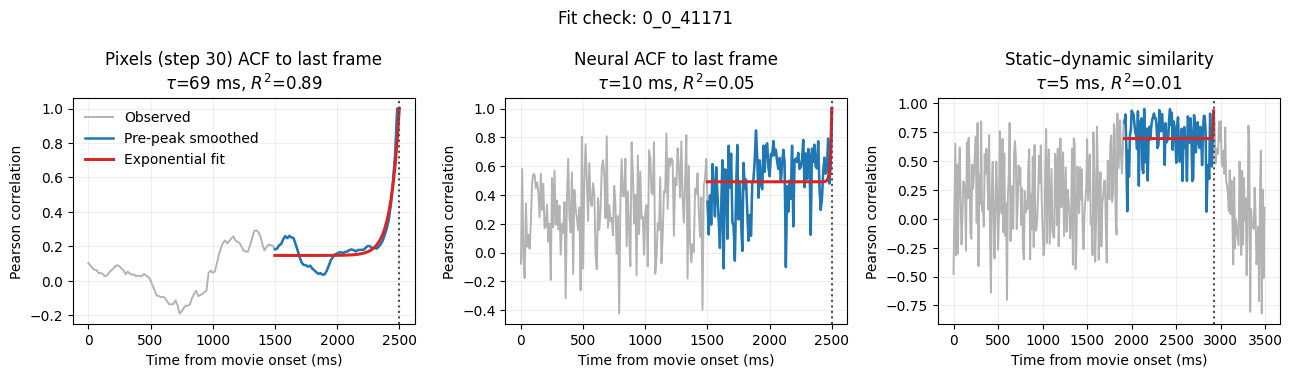

In [5]:
fit_figure, _ = plot_decay_fit_examples(
    analysis, data["stimuli"], cfg.example_stimulus_index,
)
if cfg.save_figures:
    fit_figure.savefig(
        output_dir / "example_exponential_fits.png",
        dpi=cfg.figure_dpi, bbox_inches="tight",
    )
# end if cfg.save_figures
plt.show()

## Associations over stimuli

The first three panels compare every pair of fitted $\tau$ values. The fourth uses the separately configurable static population-vector windows. The default scatterplot includes fits with $R^2 \geq 0.1$ and excludes unidentifiable fits whose $\tau$ reached a bound; the CSV retains all fits and their quality flags. Set `min_fit_r_squared=None` to disable only the $R^2$ filter.

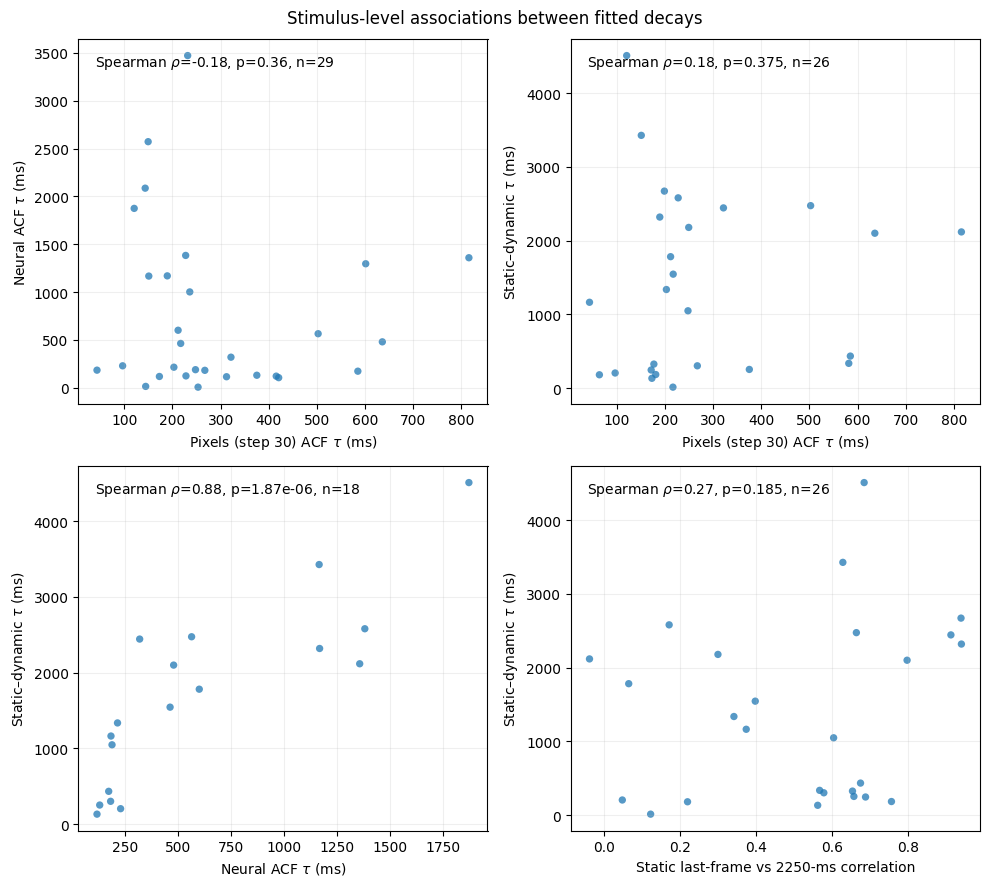

In [6]:
scatter_figure, _ = plot_decay_scatterplots(
    analysis, data["stimuli"],
    annotate_stimuli=cfg.annotate_stimuli,
    min_fit_r_squared=cfg.min_fit_r_squared,
)
if cfg.save_figures:
    scatter_figure.savefig(
        output_dir / "stimulus_decay_scatterplots.png",
        dpi=cfg.figure_dpi, bbox_inches="tight",
    )
    with open(output_dir / "stimulus_decay_parameters.csv", "w", newline="") as file:
        writer = csv.DictWriter(file, fieldnames=result_columns)
        writer.writeheader()
        writer.writerows(stimulus_results)
    # end with open
# end if cfg.save_figures
plt.show()